In [143]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
df=pd.read_csv('../data collections/random_data.csv')
df2=pd.read_csv('../data collections/random_data_2.csv')
df3=pd.read_csv('../data collections/random_data_3.csv')
df4=pd.read_csv('../data collections/random_data_3d.csv')

In [145]:
print(df.head())
print(df.nunique())
print(df.info())
df.describe()

   feature_1  feature_2  target
0   0.811586   1.977330       1
1  -0.283428  -1.368891       0
2  -0.281272   0.858368       1
3   0.617176   1.293528       1
4   1.080526   0.815136       1
feature_1    1000
feature_2    1000
target          2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  1000 non-null   float64
 1   feature_2  1000 non-null   float64
 2   target     1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


,feature_1,feature_2,target
count,1000.000000,1000.000000,1000.00000
mean,-0.012506,-0.021365,0.50000
std,1.195156,1.155874,0.50025
min,-3.650544,-3.187975,0.00000
25%,-1.049857,-1.032517,0.00000
50%,0.468185,0.127183,0.50000
75%,1.003231,0.963168,1.00000
max,1.992686,2.372060,1.00000


In [146]:
print(df2.head())
print(df2.nunique())
print(df2.info())
df2.describe()

   feature_1  feature_2  target
0   0.811586   1.977330       1
1  -0.283428  -1.368891       0
2  -0.281272   0.858368       1
3   0.617176   1.293528       1
4   1.080526   0.815136       1
feature_1    500
feature_2    500
target         2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  1000 non-null   float64
 1   feature_2  1000 non-null   float64
 2   target     1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


,feature_1,feature_2,target
count,1000.000000,1000.000000,1000.000000
mean,0.020940,-0.011339,0.496000
std,1.166321,1.156151,0.500234
min,-2.972555,-3.187975,0.000000
25%,-0.950602,-1.006720,0.000000
50%,0.478692,0.236545,0.000000
75%,1.001860,0.954061,1.000000
max,1.992686,2.344732,1.000000


In [147]:
print(df3.head())
print(df3.nunique())
print(df3.info())
print(df3.isna().sum())
df3.describe()

   Unnamed: 0  feature_1  feature_2  target
0           0   0.811586   1.977330       1
1           1  -0.283428        NaN       0
2           2  -0.281272   0.858368       1
3           3   0.617176   1.293528       1
4           4   1.080526   0.815136       1
Unnamed: 0    1000
feature_1      950
feature_2      951
target           2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1000 non-null   int64  
 1   feature_1   950 non-null    float64
 2   feature_2   951 non-null    float64
 3   target      1000 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 31.4 KB
None
Unnamed: 0     0
feature_1     50
feature_2     49
target         0
dtype: int64


,Unnamed: 0,feature_1,feature_2,target
count,1000.000000,950.000000,951.000000,1000.00000
mean,499.500000,-0.016061,-0.011498,0.50000
std,288.819436,1.203023,1.161757,0.50025
min,0.000000,-3.650544,-3.187975,0.00000
25%,249.750000,-1.058225,-1.026506,0.00000
50%,499.500000,0.474490,0.144929,0.50000
75%,749.250000,1.003046,0.974699,1.00000
max,999.000000,1.992686,2.372060,1.00000


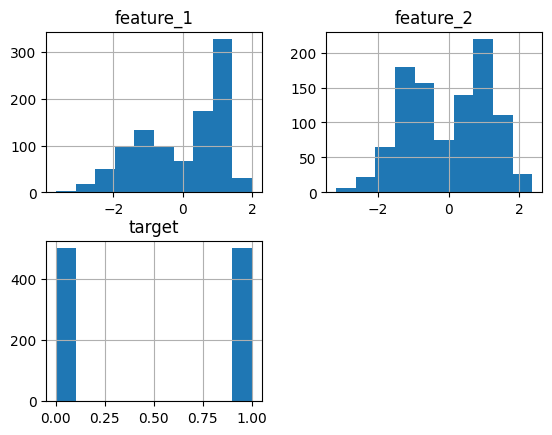

In [175]:
df.hist()
plt.show()

Dataset 1:

- Inga saknade värden
- Inga dubletter
- Inga tydliga extremvärden
- Bra balans i target varibeln

Dataset 2:

- Inga saknade värden
- Hälften av datan är dubletter
- Inga tydliga extremvärden
- Bra balans i target varibeln men något sämre än dataset 1

Dataset 3:

- 99 saknade värden
- Inga dubletter
- Inga tydliga extremvärden
- Bra balans i target variabeln 
- feature "Unnamed: 0" verkar vara index och kommer inte göra modellen bättre. 


Enligt min EDA så verkar Dataset 1 vara det bästa alternativet med antingen saknade värden eller dubbletter i de andra. Alla värden verkar vara i bra skala men eftersom SVM är känslig så kan det löna sig att skala ändå

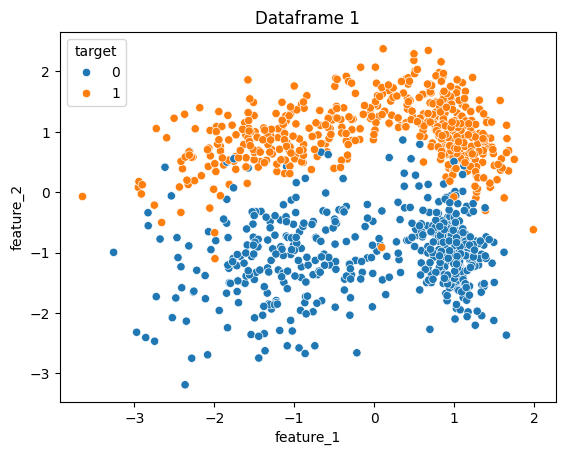

In [148]:
sns.scatterplot(x= 'feature_1', y='feature_2', hue='target', data=df)
plt.title('Dataframe 1')
plt.show()

Scatterplotten visar en tydlig skillnad på target klasserna och modellen kommer troligen göra en bra klassificering.


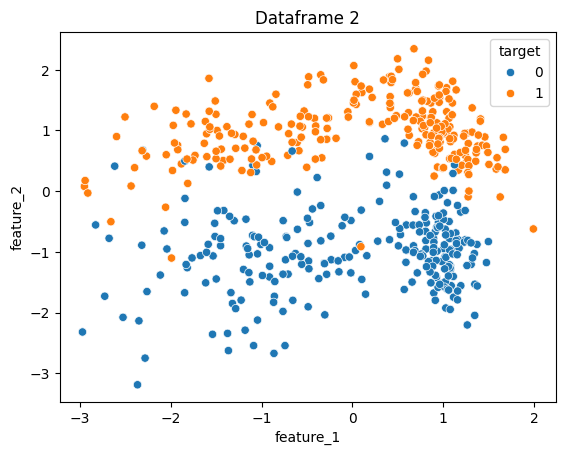

In [149]:
sns.scatterplot(x= 'feature_1', y='feature_2', hue='target', data=df2)
plt.title('Dataframe 2')
plt.show()

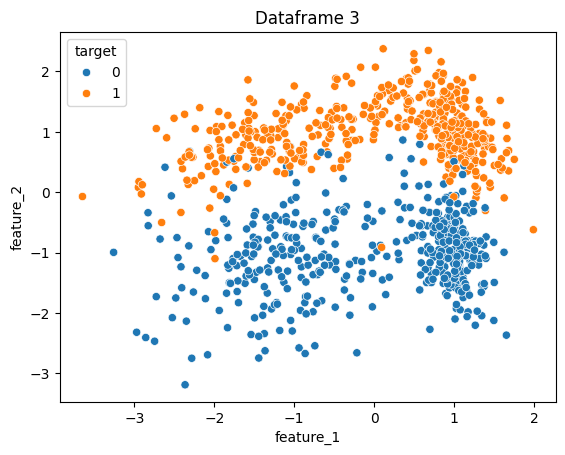

In [150]:
sns.scatterplot(x= 'feature_1', y='feature_2', hue='target', data=df3)
plt.title('Dataframe 3')
plt.show()

In [151]:
X= df.drop(['target'], axis=1)

y= df.target

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)



for c in [0.01, 0.1, 1, 10, 100]:
    model= SVC(kernel='linear', C=c, random_state=0)
    model.fit(X_train, y_train)
    print('\nc:', c, 'tränings score:', model.score(X_train, y_train))
    print('c:', c, 'test score:', model.score(X_test, y_test))

model_1= SVC(C=0.01, kernel='linear', random_state=1)


c: 0.01 tränings score: 0.95375
c: 0.01 test score: 0.975

c: 0.1 tränings score: 0.9525
c: 0.1 test score: 0.97

c: 1 tränings score: 0.9525
c: 1 test score: 0.97

c: 10 tränings score: 0.9525
c: 10 test score: 0.97

c: 100 tränings score: 0.9525
c: 100 test score: 0.97


Min modell med linjär kernel får bäst testscore när C = 0.01 med testscore: 0.975

In [152]:
for c in [0.1, 1, 10, 100]:
    for g in ['scale', 0.01, 0.1, 1]:
        model2 = SVC(kernel='rbf', C=c, gamma=g, random_state=0)
        model2.fit(X_train, y_train)
        print('\nC:', c, 'gamma:', g, 'tränings score:', model2.score(X_train, y_train))
        print('C:', c, 'gamma:', g, 'test score:', model2.score(X_test, y_test))

model_2= SVC(kernel='rbf', C=1, gamma='scale', random_state=0)


C: 0.1 gamma: scale tränings score: 0.96
C: 0.1 gamma: scale test score: 0.98

C: 0.1 gamma: 0.01 tränings score: 0.95125
C: 0.1 gamma: 0.01 test score: 0.97

C: 0.1 gamma: 0.1 tränings score: 0.9575
C: 0.1 gamma: 0.1 test score: 0.98

C: 0.1 gamma: 1 tränings score: 0.96
C: 0.1 gamma: 1 test score: 0.98

C: 1 gamma: scale tränings score: 0.96375
C: 1 gamma: scale test score: 0.99

C: 1 gamma: 0.01 tränings score: 0.955
C: 1 gamma: 0.01 test score: 0.975

C: 1 gamma: 0.1 tränings score: 0.96
C: 1 gamma: 0.1 test score: 0.98

C: 1 gamma: 1 tränings score: 0.9625
C: 1 gamma: 1 test score: 0.985

C: 10 gamma: scale tränings score: 0.965
C: 10 gamma: scale test score: 0.99

C: 10 gamma: 0.01 tränings score: 0.9575
C: 10 gamma: 0.01 test score: 0.975

C: 10 gamma: 0.1 tränings score: 0.96625
C: 10 gamma: 0.1 test score: 0.99

C: 10 gamma: 1 tränings score: 0.96875
C: 10 gamma: 1 test score: 0.985

C: 100 gamma: scale tränings score: 0.9675
C: 100 gamma: scale test score: 0.985

C: 100 gamm

När kernel= rbf ökar testscore när gamma > 0.01 eller = 'scale'. Högsta testscore är 0.99 när c= 100 och gamma= 0.1 eller 1. 

In [153]:
scaler= StandardScaler()

X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)

model_1.fit(X_train_scaled, y_train)
model_2.fit(X_train_scaled, y_train)

print('Train score:', model_1.score(X_train_scaled, y_train))
print('Test score:', model_1.score(X_test_scaled, y_test))

print('\nTrain score:', model_2.score(X_train_scaled, y_train))
print('Test score:', model_2.score(X_test_scaled, y_test))

Train score: 0.95375
Test score: 0.975

Train score: 0.965
Test score: 0.99


Resultatet av att skala om datan var en minimal förbättring för model_2 och ingen förbättring för model_1

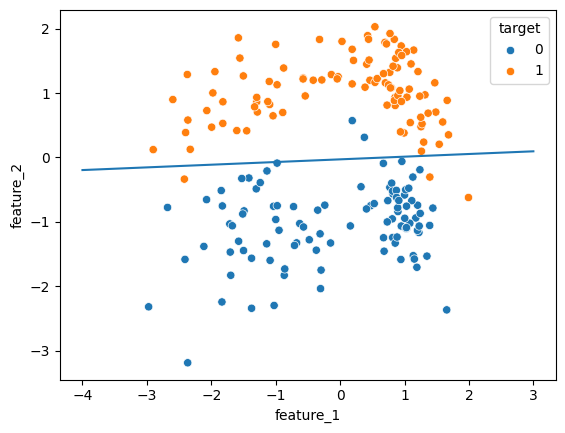

In [162]:
import numpy as np

model_1.fit(X_train, y_train)

w= model_1.coef_[0] #feature vikt
a= -w[0] / w[1] #lutning

xx= np.linspace(-4, 3)

yy = a * xx - (model_1.intercept_[0]) / w[1]

plt.plot(xx, yy)
sns.scatterplot(x= X_test['feature_1'], y=X_test['feature_2'], hue=y_test)

plt.show()

VG Del: 

In [ ]:
print(df4.head())
print(df4.nunique())
print(df4.info())
print(df4.isna().sum())
df4.describe()


   feature_1  feature_2  feature_3  target
0   1.126445   0.978839  -0.618271       1
1   0.312105   1.098053  -0.639979       1
2  -0.820462  -0.402507  -1.084069       0
3  -1.133805   0.688333  -1.082364       0
4   1.129562   0.267780  -1.086351       1
feature_1    1000
feature_2    1000
feature_3    1000
target          2
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  1000 non-null   float64
 1   feature_2  1000 non-null   float64
 2   feature_3  1000 non-null   float64
 3   target     1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None
feature_1    0
feature_2    0
feature_3    0
target       0
dtype: int64


,feature_1,feature_2,feature_3,target
count,1000.000000,1000.000000,1000.000000,1000.00000
mean,-0.019750,0.050881,0.009033,0.50000
std,1.121943,0.997245,1.166339,0.50025
min,-2.458991,-2.718469,-2.374036,0.00000
25%,-1.014670,-0.661336,-1.003989,0.00000
50%,0.106374,0.060763,-0.408566,0.50000
75%,0.981751,0.712936,1.026426,1.00000
max,2.365007,2.753076,3.362534,1.00000


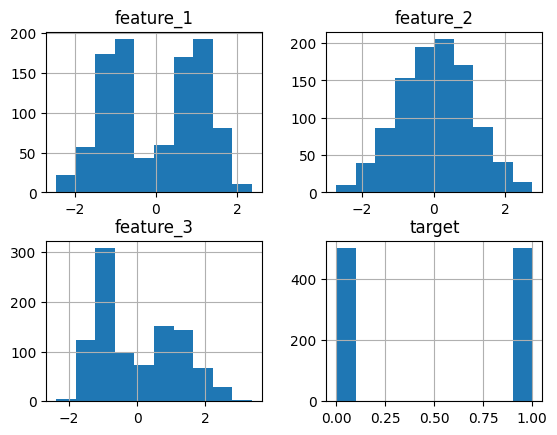

In [ ]:
df4.hist()
plt.show()

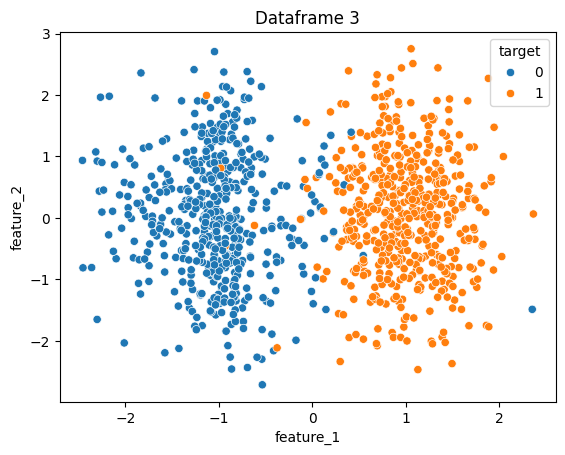

In [ ]:
sns.scatterplot(x= 'feature_1', y='feature_2', hue='target', data=df4)
plt.title('Dataframe 3')
plt.show()

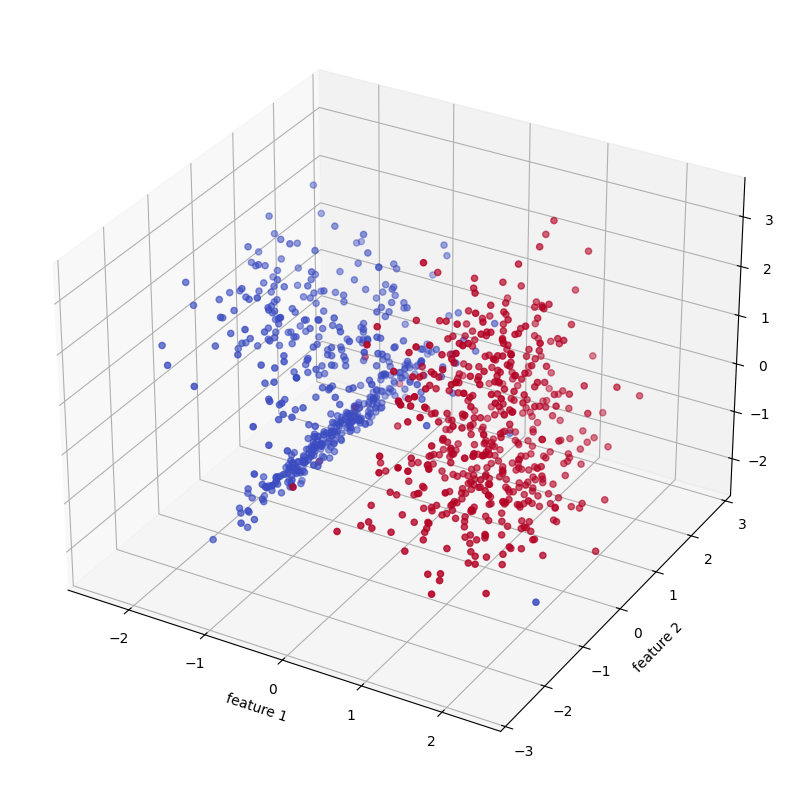

In [ ]:
fig= plt.figure(figsize=(10,10))
figure= fig.add_subplot(projection='3d')

figure.scatter(
    df4['feature_1'],
    df4['feature_2'],
    df4['feature_3'], 
    c= df4['target'],
    cmap= 'coolwarm'
)
figure.set_xlabel('feature 1')
figure.set_ylabel('feature 2')

plt.show()


bort med lite störande blå punkt:

In [163]:
#df4.sort_values('feature_2', ascending=False).head(15)
#df4.sort_values('feature_3', ascending=False).head(15)

df4_clean= df4.drop(index=926)
print(df4.sort_values('feature_1', ascending=False).head(15))
print('\n',df4_clean.sort_values('feature_1', ascending=False).head(15))




     feature_1  feature_2  feature_3  target
755   2.365007   0.062865  -1.817358       1
926   2.352846  -1.489956  -1.669098       0
105   2.044006   0.998069  -1.608507       1
494   2.027007  -0.630359  -1.541264       1
331   1.944735   1.475042   0.332684       1
593   1.938392  -0.849701  -0.306546       1
360   1.914879   0.653422  -1.489818       1
114   1.912712   0.588148  -1.539311       1
312   1.888153  -1.773257   0.471364       1
412   1.883697   2.270931  -0.430722       1
63    1.862144  -1.750945  -1.538261       1
176   1.855022   0.091560  -1.476855       1
883   1.839610   0.521131  -1.494371       1
761   1.826004  -0.430996  -1.463636       1
307   1.817474  -0.456538  -1.456119       1

      feature_1  feature_2  feature_3  target
755   2.365007   0.062865  -1.817358       1
105   2.044006   0.998069  -1.608507       1
494   2.027007  -0.630359  -1.541264       1
331   1.944735   1.475042   0.332684       1
593   1.938392  -0.849701  -0.306546       1
360   1.

In [ ]:
X= df4_clean.drop(['target'], axis=1)

y= df4_clean.target

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)



for c in [0.01, 0.1, 1, 10, 100]:
    vg_model= SVC(kernel='linear', C=c, random_state=0)
    vg_model.fit(X_train, y_train)
    print('\nc:', c, 'tränings score:', vg_model.score(X_train, y_train))
    print('c:', c, 'test score:', vg_model.score(X_test, y_test))

vg_model= SVC(C=0.01, kernel='linear', random_state=1)


c: 0.01 tränings score: 0.967459324155194
c: 0.01 test score: 0.98

c: 0.1 tränings score: 0.9724655819774718
c: 0.1 test score: 0.98

c: 1 tränings score: 0.9737171464330413
c: 1 test score: 0.98

c: 10 tränings score: 0.9749687108886108
c: 10 test score: 0.98

c: 100 tränings score: 0.9749687108886108
c: 100 test score: 0.98


In [ ]:
for c in [0.1, 1, 10, 100]:
    for g in ['scale', 0.01, 0.1, 1]:
        vg_model_2 = SVC(kernel='rbf', C=c, gamma=g, random_state=0)
        vg_model_2.fit(X_train, y_train)
        print('\nC:', c, 'gamma:', g, 'tränings score:', vg_model_2.score(X_train, y_train))
        print('C:', c, 'gamma:', g, 'test score:', vg_model_2.score(X_test, y_test))

#vg_model_2= SVC(kernel='rbf', C=1, gamma='scale', random_state=0)


C: 0.1 gamma: scale tränings score: 0.9737171464330413
C: 0.1 gamma: scale test score: 0.985

C: 0.1 gamma: 0.01 tränings score: 0.9662077596996246
C: 0.1 gamma: 0.01 test score: 0.975

C: 0.1 gamma: 0.1 tränings score: 0.9687108886107635
C: 0.1 gamma: 0.1 test score: 0.985

C: 0.1 gamma: 1 tränings score: 0.983729662077597
C: 0.1 gamma: 1 test score: 0.98

C: 1 gamma: scale tränings score: 0.9849812265331664
C: 1 gamma: scale test score: 0.98

C: 1 gamma: 0.01 tränings score: 0.967459324155194
C: 1 gamma: 0.01 test score: 0.98

C: 1 gamma: 0.1 tränings score: 0.9762202753441802
C: 1 gamma: 0.1 test score: 0.985

C: 1 gamma: 1 tränings score: 0.9849812265331664
C: 1 gamma: 1 test score: 0.985

C: 10 gamma: scale tränings score: 0.9849812265331664
C: 10 gamma: scale test score: 0.985

C: 10 gamma: 0.01 tränings score: 0.9762202753441802
C: 10 gamma: 0.01 test score: 0.985

C: 10 gamma: 0.1 tränings score: 0.9849812265331664
C: 10 gamma: 0.1 test score: 0.985

C: 10 gamma: 1 tränings sc